In [33]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

In [9]:
dataset_path = "../dataset/archive"

print(os.listdir(dataset_path)[:5])

['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05']


In [10]:
paths = []
emotions = []

emotion_dict = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

for actor in os.listdir(dataset_path):

    actor_path = os.path.join(dataset_path, actor)

    if os.path.isdir(actor_path):

        for file in os.listdir(actor_path):

            parts = file.split("-")

            if len(parts) > 2:

                emotion_code = parts[2]

                emotion = emotion_dict.get(emotion_code)

                file_path = os.path.join(actor_path, file)

                paths.append(file_path)
                emotions.append(emotion)

print("Total Files:", len(paths))

Total Files: 1440


In [12]:
def extract_mfcc(file_path):

    audio, sample_rate = librosa.load(file_path, duration=3, offset=0.5)

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sample_rate,
        n_mfcc=40
    )

    mfcc_scaled = np.mean(mfcc.T, axis=0)

    return mfcc_scaled

In [14]:
X = []
y = []

for path, emotion in zip(paths, emotions):

    mfcc_features = extract_mfcc(path)

    X.append(mfcc_features)
    y.append(emotion)

print("Feature Extraction Completed")

Feature Extraction Completed


In [15]:
X = np.array(X)
y = np.array(y)

In [16]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

y_encoded = to_categorical(y_encoded)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [18]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [19]:
model = Sequential()

model.add(Conv1D(64, 3, activation='relu', input_shape=(40,1)))
model.add(MaxPooling1D(2))

model.add(Conv1D(128, 3, activation='relu'))
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(y_encoded.shape[1], activation='softmax'))

c:\Users\thota\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.1649 - loss: 4.2673 - val_accuracy: 0.1840 - val_loss: 1.9969
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.1875 - loss: 2.0086 - val_accuracy: 0.2500 - val_loss: 1.8736
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.2127 - loss: 1.9537 - val_accuracy: 0.2708 - val_loss: 1.8703
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.2231 - loss: 1.9318 - val_accuracy: 0.2812 - val_loss: 1.8312
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.2266 - loss: 1.9359 - val_accuracy: 0.3056 - val_loss: 1.8129
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.2457 - loss: 1.8869 - val_accuracy: 0.3264 - val_loss: 1.7374
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.2691 - loss: 1.8435 - val_accuracy: 0.2986 - val_loss: 1.7777
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.2604 - loss: 1.8682 - val_accuracy: 0.3507 - 

In [22]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.4479 - loss: 1.5331
Test Accuracy: 0.4479166567325592


In [23]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


In [24]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predicted_labels
    )
)

              precision    recall  f1-score   support

           0       0.81      0.50      0.62        42
           1       0.45      0.77      0.57        44
           2       0.34      0.41      0.37        32
           3       0.47      0.53      0.50        32
           4       0.33      0.29      0.31        34
           5       0.00      0.00      0.00        20
           6       0.32      0.54      0.40        39
           7       0.81      0.29      0.43        45

    accuracy                           0.45       288
   macro avg       0.44      0.42      0.40       288
weighted avg       0.49      0.45      0.43       288



c:\Users\thota\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\thota\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\thota\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

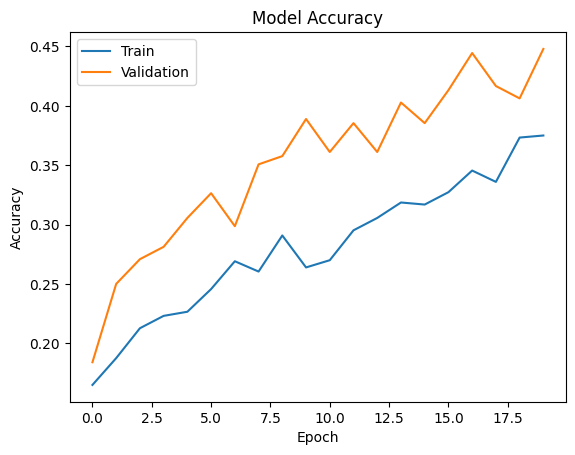

In [25]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(['Train', 'Validation'])

plt.show()

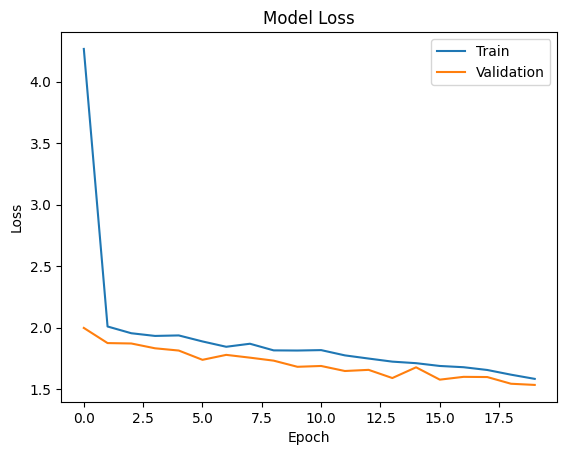

In [26]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.legend(['Train', 'Validation'])

plt.show()

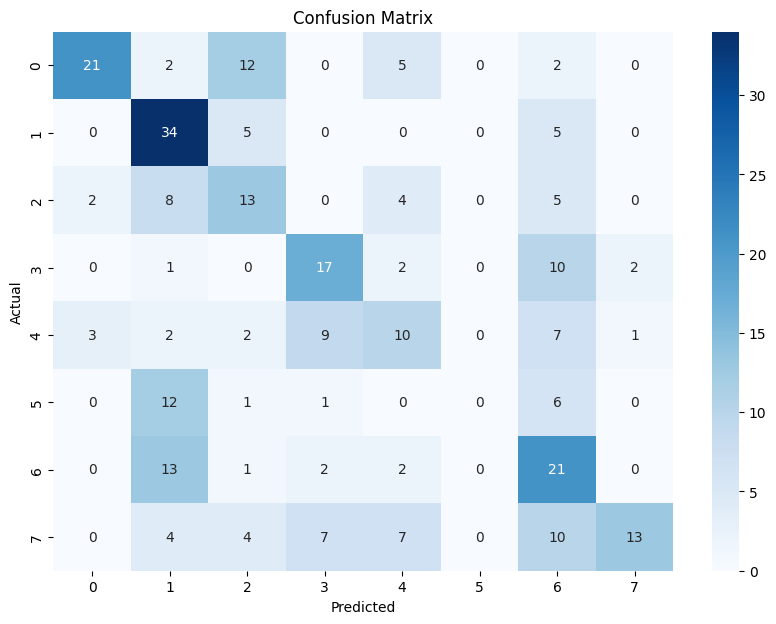

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(10,7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [31]:
import pickle

with open("label_encoder.pkl", "wb") as file:
    pickle.dump(label_encoder, file)

In [36]:
from tensorflow.keras.models import load_model

model = load_model("emotion_model.h5", compile=False)

model.save("fixed_emotion_model.keras")



In [37]:
import os

for file in os.listdir():
    print(file)

EmotionRecognition.ipynb
emotion_model.h5
fixed_emotion_model.keras
label_encoder.pkl
